# S10: Growth and extreme points of a function


In [ ]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from sympy import Function, diff, Symbol, latex
from sympy.plotting import plot
from IPython.display import Math, display

# Extreme points of a function

Let us examine the plot of this function to identify the intervals where it increases or decreases and its local extreme values.  

In [ ]:
x = sy.Symbol('x')
f = sy.exp(x) * (x**2 - 3 * x + 1)
display(Math(f"f(x) = {latex(f)}"))


<IPython.core.display.Math object>

Let us begin by computing the derivative and trying to factor it to better understand its sign:

In [ ]:
df = sy.factor(sy.diff(f, x))
display(Math(f"f'(x) = {latex(df)}"))

<IPython.core.display.Math object>

We also find the critical points. Since $f'$ exists everywhere, these are the zeros of $f'$.

In [ ]:
critical_points = sy.solve(df, x)
display(Math(f"\\text{{ Critical points of }} f(x): {latex(set(critical_points))}"))

<IPython.core.display.Math object>

Next we plot it. We select by trial and error a plotting interval that fits the critical points (not too small, not too large):

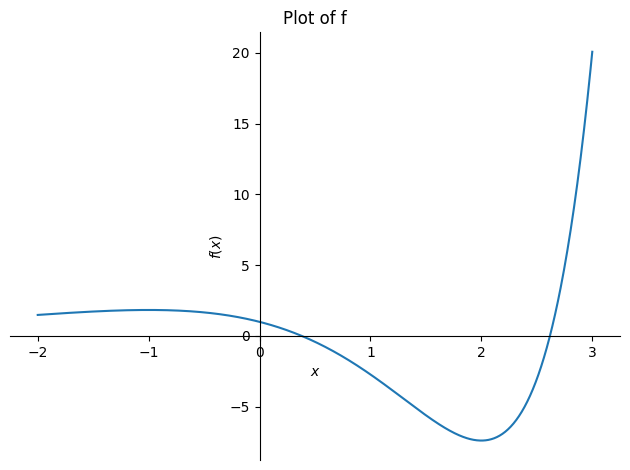

In [ ]:
plot_f = sy.plotting.plot(f, (x, -2, 3), show=False, title='Plot of f')
plot_f.show()

A more elaborate plot showing the extreme values can be obtained by switching to numpy and matplotlib:

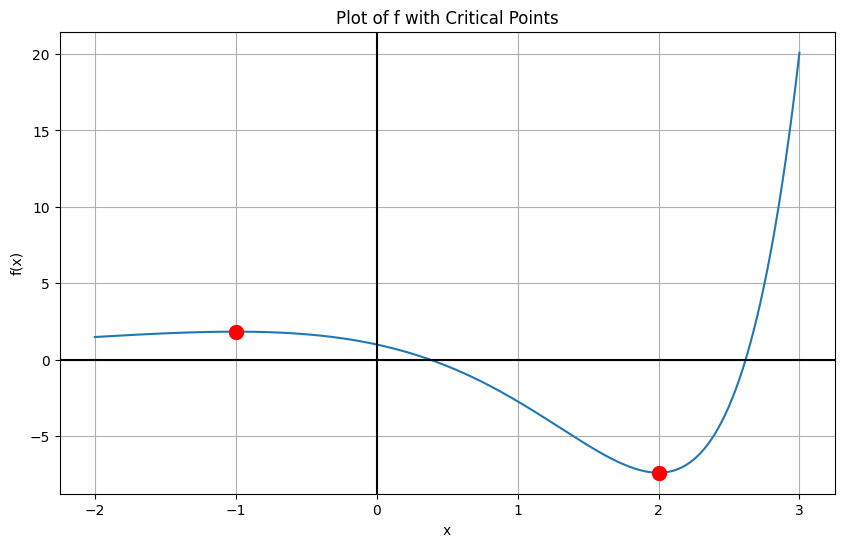

In [ ]:

# Convert sympy expression to a numerical function for plotting with matplotlib
f_numeric = sy.lambdify(x, f, 'numpy')

# Define the range for plotting
x_vals = np.linspace(-2, 3, 400)
y_vals = f_numeric(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='$f(x)$')

# Plot critical points
critical_points_list = list(critical_points)
critical_y_vals = [f_numeric(float(cp)) for cp in critical_points_list] # Convert Sympy Integers to floats
plt.scatter(critical_points_list, critical_y_vals, color='red', marker='o', s=100, zorder=5, label='Critical Points')

plt.title('Plot of f with Critical Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.show()

You are invited to think about this graph and find segments of type (a), (b), (c), (d) as described in the lecture notes.

# Higher order derivatives and extreme points

Analyze if the origin is an extreme point of $f$ and in that case identify its type.

In [ ]:
f = 4 + sy.sin(x**6) + sy.cos(x**3) - sy.exp(x**6) + x**6/2
display(Math(f"f(x) = {latex(f)}"))

<IPython.core.display.Math object>

The key here is to look at the taylor polynomial and locate the first non zero derivative after checking that the first derivative equals 0.

In [ ]:
f_series = sy.series(f, x, 0, 20)
display(Math(f"f(x) = {latex(f_series)}"))

<IPython.core.display.Math object>

Now we can plot the function close to the origin:

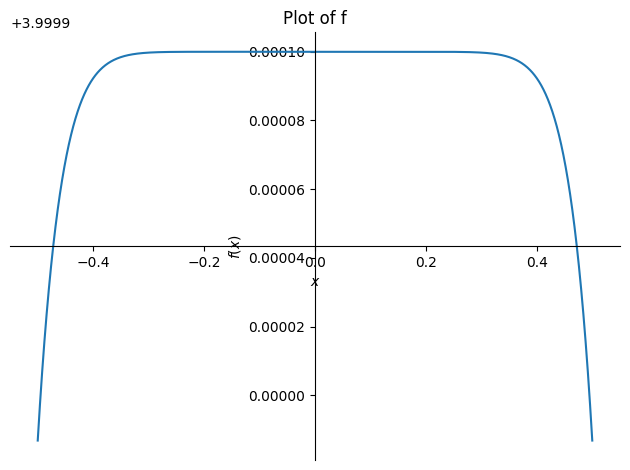

In [ ]:
sy.plotting.plot(f, (x, -1/2, 1/2), title='Plot of f')
